# Features: every lounge and every growth area, at any assumption level

The market model's three parts (`market_size.ipynb`, `catchments.ipynb`, `competitors.ipynb`) come
together here in one function, `src.features.lounges.build(v3, assumptions, levels, closed)`. It
returns a `LoungeFeatures` row per open lounge (catchment women, competition, capture) and an `Area`
per growth candidate (populated cells no open lounge reaches). The app calls it on every click, so
it takes ~20 ms. This notebook has **no model logic of its own**: it calls `build` and plots what
comes back, at each assumption level.

Data: `data/seed/v3/` via `src.data_v3.load_v3()`; assumptions in `data/scenarios/baseline.yaml`.

## 1. What `build` does

**Per open lounge**, at the chosen levels:
1. **Catchment** = the cells within the travel time (`catchment_cells.csv`, 10 / **15** / 20 min);
   **women** = women 15+ in them (worker-housing share 1% / **5.5%** / 15%); **addressable women**
   = the same women weighted by their cell's observed Dubai rent (affluence off / **medium** /
   strong; neutral where no rent is observed, i.e. everywhere outside 241 Dubai cells;
   `affluence.ipynb`).
2. **Shared share** = the share of those women in cells another *open* lounge also reaches.
3. **Competition** = premium salons among the lounge's candidates at that travel time (other open
   Bedashing lounges included, closed ones removed); the substitutes are the most-reviewed premium
   salons holding 50 / **60** / 70% of their reviews, scaled up by the recall multiplier for that
   travel time's polygon. **Capture** = lounge reviews ÷ (lounge + substitutes); **estimated
   customers** = capture x addressable women. `thin_premium_market` flags fewer than 10 premium salons.
4. The **airport lounge** gets a row but is not scored (it serves travellers): its estimated customers are 0.

**Growth areas** = populated cells in no open lounge's catchment (the airport's counts as reached),
grouped by their OSM name and emirate and split into touching pieces. Competition over an area uses
only the cells our search covered (a search circle contains the cell centre): premium salons, their
reviews per 1,000 women (recall-corrected), and the share of the area's women with that data.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import itertools
import time
from math import cos, radians

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch, Rectangle
from shapely import make_valid
from shapely.affinity import scale
from shapely.geometry import Point, shape
from shapely.ops import unary_union

from src.config import load_baseline_assumptions, settings
from src.data_v3 import LEVELS, load_v3
from src.features.lounges import NOT_SCORED, build
from src.market import capture_by_coverage, premium_substitutes, recall_multiplier, women_15plus
from src.models import Levels

pd.set_option("display.width", 160)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.2, "grid.color": "#888", "axes.edgecolor": "#999", "font.size": 9})
BLUE, ORANGE, AQUA, YELLOW, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9e9e9e"
LEVEL_COLOR = {"low": AQUA, "medium": BLUE, "high": ORANGE}

A = load_baseline_assumptions(ROOT / "data/scenarios/baseline.yaml")
v3 = load_v3()
t0 = time.perf_counter(); build(v3, A); first = time.perf_counter() - t0
t0 = time.perf_counter(); feats, areas = build(v3, A); again = time.perf_counter() - t0
print(f"build: {first * 1000:.0f} ms the first time (lookups), {again * 1000:.0f} ms after; "
      f"{len(feats)} lounges, {len(areas)} growth areas at medium levels")

df = lambda rows: pd.DataFrame([r.model_dump() for r in rows])
F = {lv: df(build(v3, A, Levels(travel=lv))[0]).set_index("branch_id") for lv in LEVELS}   # by travel level
med = F["medium"]
order = med.sort_values("catchment_women").index

build: 122 ms the first time (lookups), 25 ms after; 24 lounges, 580 growth areas at medium levels


## 2. The assumptions used here

| Assumption | low / **medium** / high | Evidence |
|---|---|---|
| Travel time (catchment) | 10 / **15** / 20 min | `catchments.ipynb`, SOURCES.md "Catchment travel time" |
| Competitor coverage (substitutes) | 50 / **60** / 70% of premium reviews | `competitors.ipynb` |
| Worker-housing female share | 1 / **5.5** / 15% | `market_size.ipynb` (DSC 2022 labour-camp communities) |
| Search recall where circles are full | 0.66 | Al Barsha probe, `competitors.ipynb` |
| Thin premium market | fewer than 10 premium salons | capture is a share of a tiny pool |
| Not scored | `zayed-international-airport` | serves travellers, not its catchment |

## 3. Catchment women per lounge, at each travel time

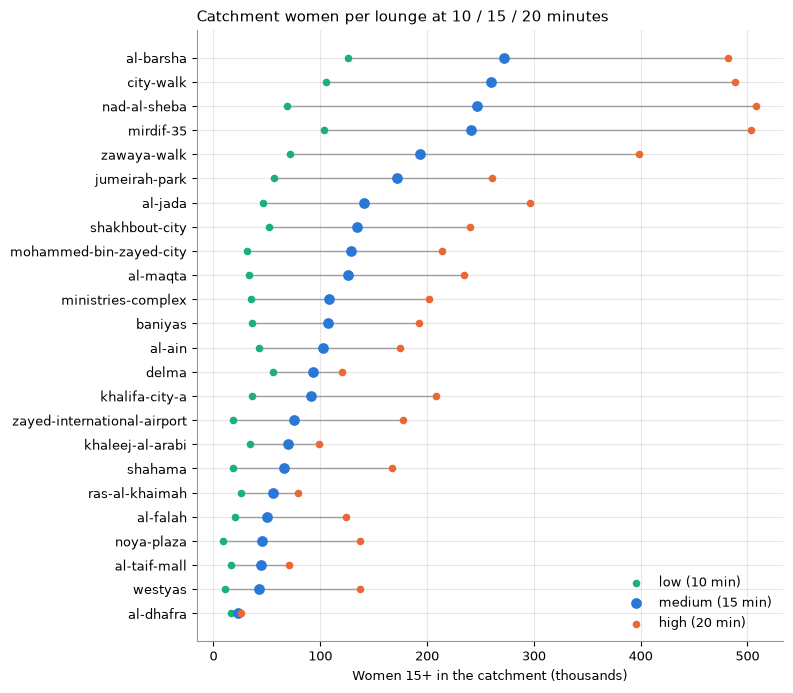

,women_low,women_medium,women_high
branch_id,,,
al-barsha,126160.0,272371.0,481992.0
city-walk,105298.0,259919.0,488701.0
nad-al-sheba,69070.0,247186.0,508323.0
mirdif-35,103840.0,241393.0,503015.0
zawaya-walk,71301.0,193382.0,398111.0
jumeirah-park,56220.0,171595.0,261220.0
al-jada,46212.0,141330.0,296216.0
shakhbout-city,52357.0,134564.0,240058.0
mohammed-bin-zayed-city,31643.0,129056.0,214185.0


In [2]:
fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(order))
for lv in LEVELS:
    ax.scatter(F[lv].catchment_women.reindex(order) / 1000, y, s=45 if lv == "medium" else 20,
               color=LEVEL_COLOR[lv], zorder=3, label=f"{lv} ({A.travel_time_minutes[lv]} min)")
ax.hlines(y, F["low"].catchment_women.reindex(order) / 1000, F["high"].catchment_women.reindex(order) / 1000, color=GREY, lw=1)
ax.set_yticks(y, order)
ax.set_xlabel("Women 15+ in the catchment (thousands)")
ax.set_title("Catchment women per lounge at 10 / 15 / 20 minutes", loc="left")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()
pd.DataFrame({f"women_{lv}": F[lv].catchment_women for lv in LEVELS}).reindex(order[::-1]).round(0)

## 4. Competition per travel time, next to the women

A longer drive brings in more women **and** more premium salons, so capture doesn't simply rise
with the catchment. Each panel is one quantity; the dots are the three travel times.

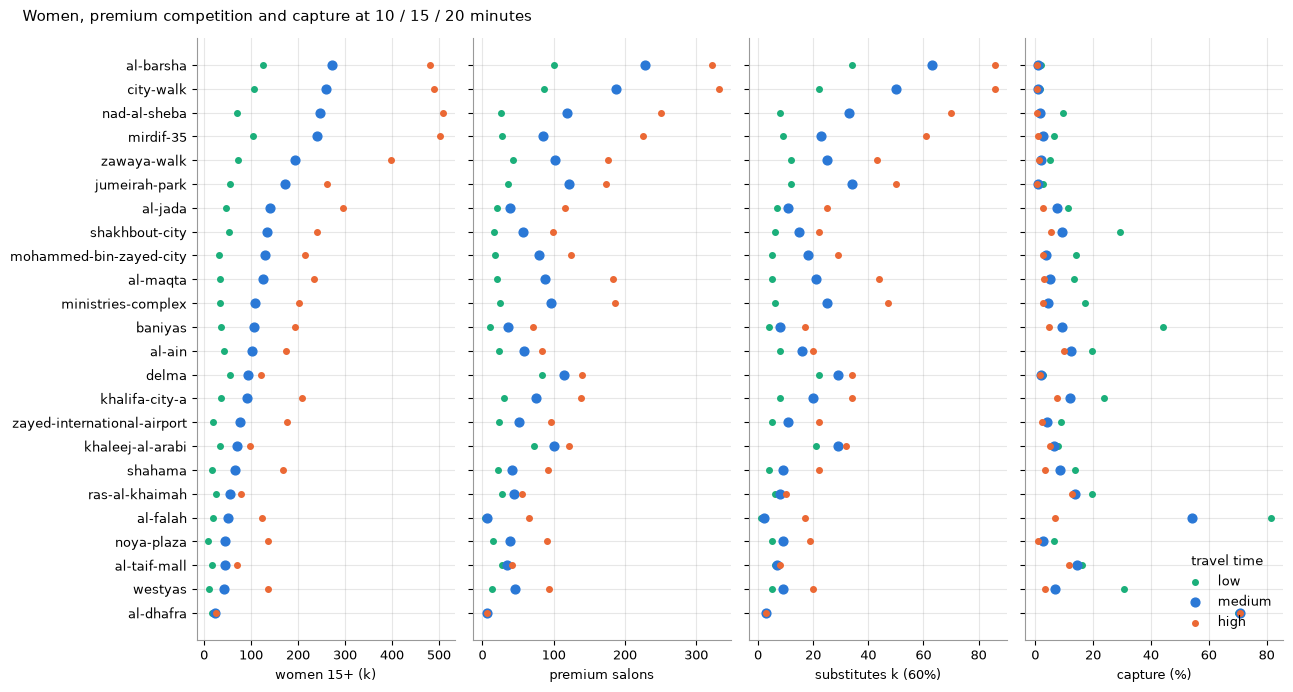

low                                                           medium                                                   \
                            catchment_women premium_pool substitutes_k capture est_customers catchment_women premium_pool substitutes_k capture est_customers   
branch_id                                                                                                                                                       
al-barsha                        126160.478          100            34   0.020      2969.975      272370.641          228            63   0.008      2609.856   
city-walk                        105297.614           86            22   0.018      2190.207      259918.887          187            50   0.010      2790.323   
nad-al-sheba                      69070.304           26             8   0.095      6800.240      247185.968          119            33   0.016      3820.041   
mirdif-35                        103840.300           27             9   0.066      6848.029      241392.586           85            23   0.027      6151.353   
zawaya-walk                       71300.766           43            12   0.052      3678.380      193381.987          102            25   0.020      3909.550   
jumeirah-park                     56219.627           36            12   0.027      1866.399      171594.807          121            34   0.010      1723.617   
al-jada                           46212.373           21             7   0.114      5280.503      141329.535           38            11   0.074     10461.821   
shakhbout-city                    52357.352           16             6   0.294     15379.210      134563.906           57            15   0.091     12239.498   
mohammed-bin-zayed-city           31643.444           18             5   0.141      4475.366      129055.690           80            18   0.036      4658.966   
al-maqta                          33375.663           21             5   0.133      4452.180      126053.626           88            21   0.052      6542.342   
ministries-complex                34920.620           25             6   0.171      5957.111      107721.678           96            25   0.044      4765.862   
baniyas                           36522.945           11             4   0.443     16171.276      106825.818           36             8   0.094      9999.472   
al-ain                            42465.060           23             8   0.195      8285.451      102438.955           59            16   0.123     12617.500   
delma                             55271.163           83            22   0.026      1436.275       93189.987          114            29   0.021      1926.792   
khalifa-city-a                    36121.325           30             8   0.239      8629.144       91431.593           75            20   0.122     11139.950   
zayed-international-airport       18363.600           23             5   0.088         0.000       75830.155           51            11   0.039         0.000   
khaleej-al-arabi                  34447.704           72            21   0.078      2679.712       69366.590          100            29   0.065      4510.830   
shahama                           17812.163           22             4   0.138      2466.633       65769.157           41             9   0.085      5615.562   
ras-al-khaimah                    25466.183           27             6   0.195      4974.677       55839.696           44             8   0.138      7713.239   
al-falah                          19977.413            3             1   0.816     16305.830       49946.829            6             2   0.542     27054.286   
noya-plaza                         9255.205           15             5   0.065       600.842       45036.581           39             9   0.027      1223.296   
al-taif-mall                      16819.679           28             6   0.161      2705.803       44817.810           35             7   0.143      6401.959   
westyas        

In [3]:
cols = [("catchment_women", "women 15+ (k)", 1000), ("premium_pool", "premium salons", 1),
        ("substitutes_k", "substitutes k (60%)", 1), ("capture", "capture (%)", 0.01)]
fig, axes = plt.subplots(1, 4, figsize=(13, 7), sharey=True)
for ax, (c, label, div) in zip(axes, cols):
    for lv in LEVELS:
        ax.scatter(F[lv][c].reindex(order) / div, y, s=40 if lv == "medium" else 16, color=LEVEL_COLOR[lv], zorder=3, label=lv)
    ax.set_xlabel(label)
axes[0].set_yticks(y, order)
axes[-1].legend(frameon=False, loc="lower right", title="travel time")
fig.suptitle("Women, premium competition and capture at 10 / 15 / 20 minutes", x=0.02, ha="left")
plt.tight_layout(); plt.show()
t = pd.concat({lv: F[lv][["catchment_women", "premium_pool", "substitutes_k", "capture", "est_customers"]] for lv in LEVELS}, axis=1)
t.reindex(order[::-1]).round(3)

## 5. Is the 20-minute polygon covered by the salon search?

The search circles (catchment run plus growth run) were laid over the 15-min polygons and over the
growth cells. A 20-min polygon reaches further, so check the share of each one under a searched
circle; uncovered parts mean candidates we never saw, so the 20-min competition is a lower bound there.

share of each 20-min polygon under a search circle:
ras-al-khaimah                 0.929
al-falah                       0.930
shahama                        0.930
al-ain                         0.935
al-dhafra                      0.938
baniyas                        0.950
al-taif-mall                   0.951
al-jada                        0.961
zayed-international-airport    0.974
shakhbout-city                 0.974
khalifa-city-a                 0.978
jumeirah-park                  0.983
al-barsha                      0.984
nad-al-sheba                   0.987
mirdif-35                      0.995
mohammed-bin-zayed-city        0.996
al-maqta                       0.997
westyas                        0.999
ministries-complex             1.000
city-walk                      1.000
delma                          1.000
noya-plaza                     1.000
khaleej-al-arabi               1.000
zawaya-walk                    1.000


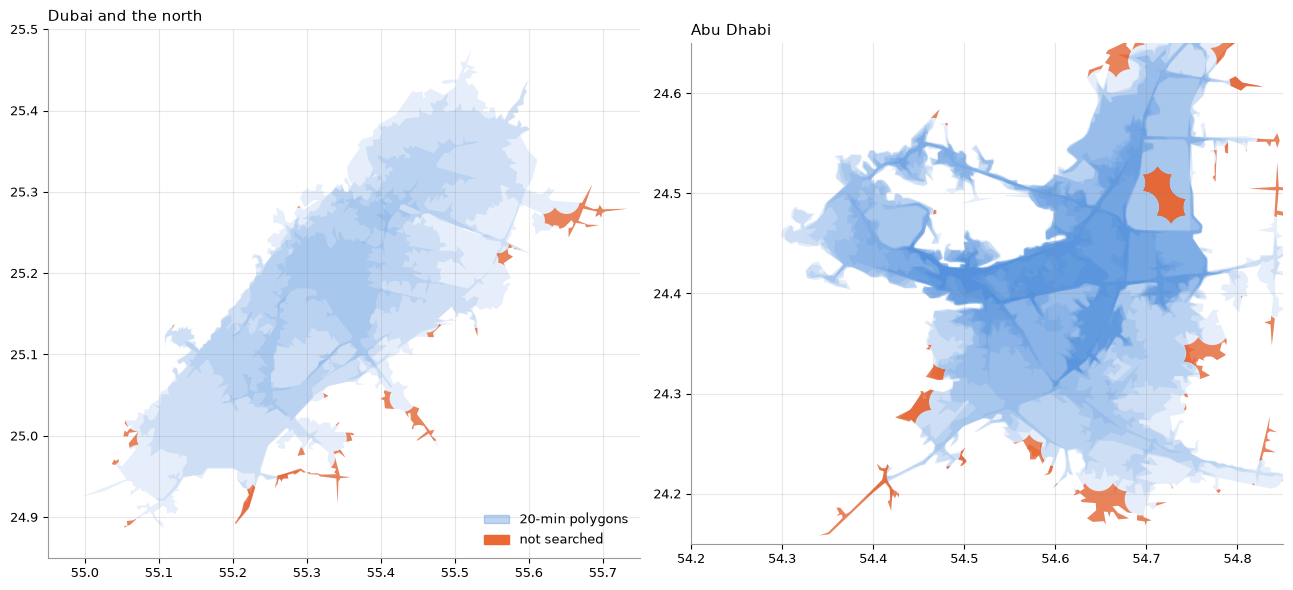

In [4]:
disks = unary_union([scale(Point(r.lng, r.lat).buffer(r.radius_m / 111_000), xfact=1 / cos(radians(r.lat)))
                     for r in v3.circles.itertuples()])
poly20 = {lo.branch_id: make_valid(shape(v3.polygons[(lo.branch_id, 20)])) for lo in v3.lounges}
cover = pd.Series({b: p.intersection(disks).area / p.area for b, p in poly20.items()}).sort_values()
print("share of each 20-min polygon under a search circle:")
print(cover.round(3).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (title, ext) in zip(axes, [("Dubai and the north", (54.95, 55.75, 24.85, 25.5)), ("Abu Dhabi", (54.2, 54.85, 24.15, 24.65))]):
    for b, p in poly20.items():
        for g in getattr(p, "geoms", [p]):
            if g.geom_type == "Polygon":
                ax.fill(*g.exterior.xy, color=BLUE, alpha=0.12, lw=0)
        hole = p.difference(disks)
        for g in getattr(hole, "geoms", [hole]):
            if g.geom_type == "Polygon" and not g.is_empty:
                ax.fill(*g.exterior.xy, color=ORANGE, alpha=0.8, lw=0)
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_aspect(1 / 0.91); ax.set_title(title, loc="left")
axes[0].legend(handles=[Patch(color=BLUE, alpha=0.3, label="20-min polygons"), Patch(color=ORANGE, label="not searched")], frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

## 6. Shared catchment between lounges

Row lounge, column lounge: the share of the row lounge's catchment women (15 min) who live in cells
the column lounge also reaches. `shared_share` in the features is the share reached by *any* other
lounge. The ten Abu Dhabi city lounges share 98-100% of their women with each other; Dubai and Sharjah lounges share
47-86%; al-ain, al-dhafra, al-taif-mall and ras-al-khaimah share nothing.

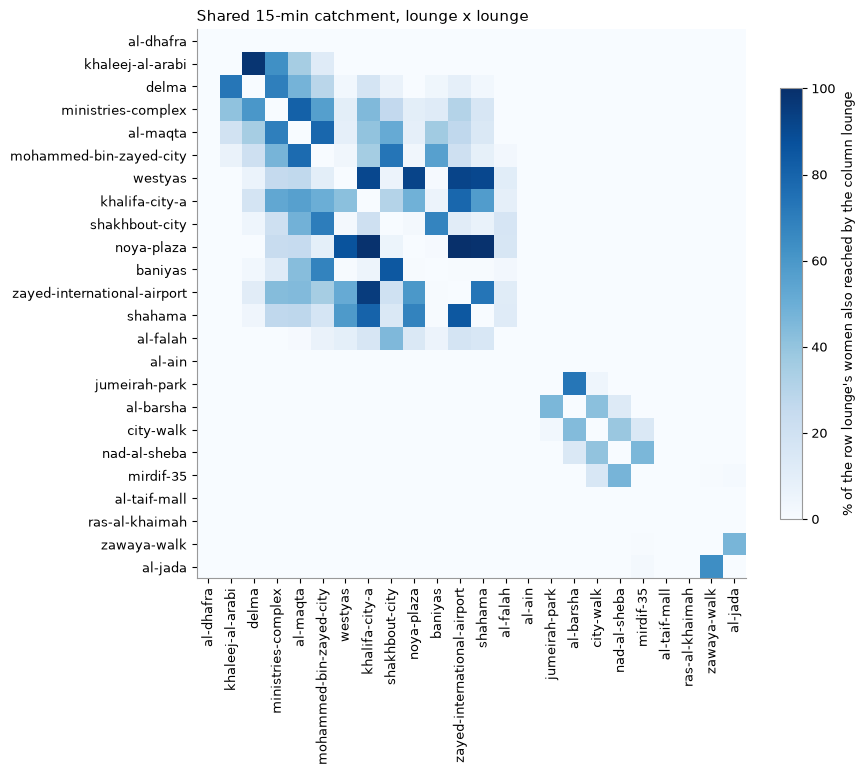

branch_id,khalifa-city-a,al-maqta,noya-plaza,mohammed-bin-zayed-city,ministries-complex,zayed-international-airport,westyas,shakhbout-city,khaleej-al-arabi,delma,...,jumeirah-park,city-walk,al-jada,al-falah,mirdif-35,zawaya-walk,al-taif-mall,ras-al-khaimah,al-dhafra,al-ain
emirate,Abu Dhabi,Abu Dhabi,Abu Dhabi,Abu Dhabi,Abu Dhabi,Abu Dhabi,Abu Dhabi,Abu Dhabi,Abu Dhabi,Abu Dhabi,...,Dubai,Dubai,Sharjah,Abu Dhabi,Dubai,Sharjah,Fujairah,Ras Al Khaimah,Abu Dhabi,Abu Dhabi
catchment_women,91431.59,126053.63,45036.58,129055.69,107721.68,75830.15,42368.07,134563.91,69366.59,93189.99,...,171594.81,259918.89,141329.54,49946.83,241392.59,193381.99,44817.81,55839.7,22927.3,102438.95
shared_share,1.0,1.0,1.0,1.0,1.0,1.0,0.98,0.98,0.98,0.98,...,0.73,0.72,0.66,0.57,0.52,0.47,0.0,0.0,0.0,0.0


In [5]:
women = women_15plus(v3.cells, v3.emirates, A.worker_housing_female_share["medium"])
catch = v3.catchment[v3.catchment.level == "medium"].groupby("branch_id").cell_id.agg(set)
ids = list(med.sort_values(["emirate", "lng"]).index)
M = pd.DataFrame([[0 if a == b else women[list(catch[a] & catch[b])].sum() / women[list(catch[a])].sum() for b in ids] for a in ids], ids, ids)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(M * 100, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(ids)), ids, rotation=90); ax.set_yticks(range(len(ids)), ids); ax.grid(False)
plt.colorbar(im, ax=ax, shrink=0.7, label="% of the row lounge's women also reached by the column lounge")
ax.set_title("Shared 15-min catchment, lounge x lounge", loc="left")
plt.tight_layout(); plt.show()
med[["emirate", "catchment_women", "shared_share"]].sort_values("shared_share", ascending=False).round(2).T

## 7. Growth areas

Cells with women that no open lounge reaches at 15 minutes, grouped by OSM name and split into
touching pieces. Orange: areas with at least 5,000 women (darker = more); grey: reached cells.

580 growth areas: 68 with >= 5k women, 7 with >= 20k; 1,447,191 women in all; 327 areas have no searched cell


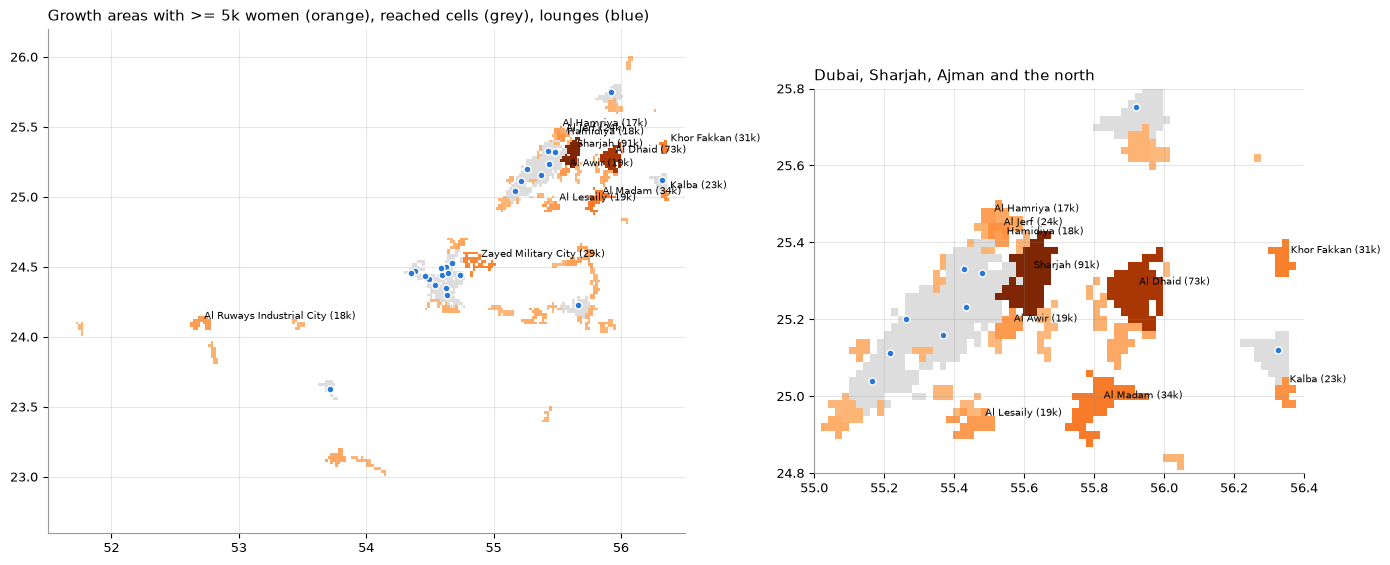

,area_id,name,emirate,lat,lng,women,addressable_women,affluence_rent,affluence_coverage,cells,worker_share,premium_salons,premium_reviews_per_1k,full_circle_share,data_coverage,nearest_lounge_id,nearest_lounge_km
0,sharjah-sharjah,Sharjah,Sharjah,25.32,55.61,90605.79,90605.79,NaN,0.00,50,0.11,15.0,21.93,0.17,0.96,al-jada,13.26
1,al-dhaid-sharjah,Al Dhaid,Sharjah,25.28,55.91,73067.03,73067.03,NaN,0.00,54,0.02,8.0,5.43,0.12,0.82,al-jada,43.78
2,al-madam-sharjah,Al Madam,Sharjah,24.98,55.81,33678.55,33678.55,NaN,0.00,41,0.01,1.0,1.05,0.00,0.42,mirdif-35,47.35
3,khor-fakkan-sharjah,Khor Fakkan,Sharjah,25.36,56.35,31162.57,31162.57,NaN,0.00,11,0.01,11.0,28.48,0.40,0.94,al-taif-mall,26.50
4,zayed-military-city-abu-dhabi,Zayed Military City,Abu Dhabi,24.53,54.86,29181.10,29181.10,NaN,0.00,45,0.02,0.0,0.00,0.00,0.23,al-falah,15.51
5,al-jerf-ajman,Al Jerf,Ajman,25.43,55.53,23851.19,23851.19,NaN,0.00,5,0.05,11.0,59.44,0.80,1.00,al-jada,13.20
6,kalba-sharjah,Kalba,Sharjah,25.02,56.34,23464.26,23464.26,NaN,0.00,8,0.00,6.0,44.09,0.00,0.98,al-taif-mall,11.10
7,al-awir-dubai,Al Awir,Dubai,25.18,55.55,19386.74,20078.07,170000.0,0.38,11,0.00,1.0,1.27,0.00,0.86,mirdif-35,13.59
8,al-lesaily-dubai,Al Lesaily,Dubai,24.93,55.47,18812.40,17230.61,38794.0,0.21,16,0.01,3.0,2.94,0.00,0.80,nad-al-sheba,27.08
9,al-ruways-industrial-city-abu-dhabi,Al Ruways Industrial City,Abu Dhabi,24.09,52.68,18098.69,18098.69,NaN,0.00,28,0.59,2.0,13.33,0.00,0.57,al-dhafra,116.55


In [6]:
ar = df(areas)
print(f"{len(ar)} growth areas: {(ar.women >= 5000).sum()} with >= 5k women, {(ar.women >= 20000).sum()} with >= 20k; "
      f"{ar.women.sum():,.0f} women in all; {ar.premium_salons.isna().sum()} areas have no searched cell")
reached = set(v3.catchment[v3.catchment.level == "medium"].cell_id)
cells = v3.cells
big = ar[ar.women >= 5000]
cell_area = {c: a for a, cs in zip(big.area_id, big.cell_ids) for c in cs}
vmax = big.women.max()
fig, axes = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={"width_ratios": [1.3, 1]})
for ax, ext in zip(axes, [(51.5, 56.5, 22.6, 26.2), (55.0, 56.4, 24.8, 25.8)]):
    for r in cells.itertuples():
        if r.Index in reached:
            ax.add_patch(Rectangle((r.west, r.south), r.east - r.west, r.north - r.south, color="#ddd", lw=0))
        elif r.Index in cell_area:
            w = big.set_index("area_id").women[cell_area[r.Index]]
            ax.add_patch(Rectangle((r.west, r.south), r.east - r.west, r.north - r.south, lw=0,
                                   color=plt.get_cmap("Oranges")(0.3 + 0.7 * w / vmax)))
    for lo in v3.lounges:
        ax.scatter(lo.lng, lo.lat, s=25, color=BLUE, edgecolor="white", zorder=3)
    for a in big.head(12).itertuples():
        if ext[0] < a.lng < ext[1] and ext[2] < a.lat < ext[3]:
            ax.annotate(f"{a.name} ({a.women / 1000:.0f}k)", (a.lng, a.lat), fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_aspect(1 / 0.91)
axes[0].set_title("Growth areas with >= 5k women (orange), reached cells (grey), lounges (blue)", loc="left")
axes[1].set_title("Dubai, Sharjah, Ajman and the north", loc="left")
plt.tight_layout(); plt.show()
ar.drop(columns="cell_ids").head(20).round(2)

## 8. Checks at medium levels

**Catchment women** must equal `market_size.ipynb` / `competitors.ipynb` (women 15+ in the medium
catchment cells). **Capture and k** were computed in `competitors.ipynb` from the 15-min record
(`lounge_candidates.csv`, `lounge_search_saturation.csv`). `build` uses the per-level files instead,
which differ in two ways: (1) the medium candidates are a **superset** of that record, because the
growth run (Task 2) found salons inside some 15-min polygons that the catchment run had missed; (2)
the full share is measured over the full-detail polygon and includes growth circles that overlap it.
So capture and k move slightly for the lounges below. Rerunning the record's own maths here:

In [7]:
w15 = women_15plus
D = settings.v3_dir
c = v3.catchment[v3.catchment.level == "medium"]
ref_women = c.assign(w=c.cell_id.map(w15(v3.cells, v3.emirates, A.worker_housing_female_share["medium"]))).groupby("branch_id").w.sum()
print("catchment women equal to the notebooks' recomputation:", np.allclose(ref_women.reindex(med.index), med.catchment_women))

rows = v3.salons.reset_index().set_index("place_id", drop=False).to_dict("index")
rec = pd.read_csv(D / "lounge_candidates.csv").groupby("branch_id").place_id.agg(list)
sat = pd.read_csv(D / "lounge_search_saturation.csv").set_index("branch_id").full_share
out = []
for b, r in med.iterrows():
    cands = [rows[p] for p in rec[b]]
    prem = premium_substitutes(cands, len(cands), A.premium_min_rating, A.comparable_price_levels)
    cap, k = capture_by_coverage(r.review_count, prem, A.competitor_coverage["medium"], recall_multiplier(sat[b], A.search_recall))
    out.append({"branch_id": b, "candidates_record": len(cands), "candidates_now": len(v3.candidates[(b, "medium")]),
                "premium_record": len(prem), "premium_now": r.premium_pool, "full_share_record": sat[b],
                "full_share_now": v3.full_share[(b, "medium")], "k_record": k, "k_now": r.substitutes_k,
                "capture_record": cap, "capture_now": r.capture})
cmp = pd.DataFrame(out).set_index("branch_id")
cmp["capture_change"] = cmp.capture_now / cmp.capture_record - 1
diff = cmp[(cmp.k_record != cmp.k_now) | (cmp.capture_change.abs() > 1e-9)]
print(f"{len(diff)} of {len(cmp)} lounges differ; largest capture change {cmp.capture_change.abs().max():.1%}")
diff.round(4)

catchment women equal to the notebooks' recomputation: True
13 of 24 lounges differ; largest capture change 4.2%


,candidates_record,candidates_now,premium_record,premium_now,full_share_record,full_share_now,k_record,k_now,capture_record,capture_now,capture_change
branch_id,,,,,,,,,,,
al-ain,213,218,58,59,0.1875,0.2619,16,16,0.1269,0.1232,-0.0296
al-barsha,507,528,220,228,0.5915,0.5761,60,63,0.0083,0.0081,-0.0160
al-jada,176,176,38,38,0.4865,0.4167,11,11,0.0720,0.0740,0.0274
al-taif-mall,117,117,35,35,0.1463,0.1489,7,7,0.1430,0.1428,-0.0011
city-walk,465,477,184,187,0.7547,0.7385,49,50,0.0101,0.0100,-0.0088
jumeirah-park,276,292,115,121,0.4902,0.4925,32,34,0.0103,0.0099,-0.0299
khalifa-city-a,243,243,75,75,0.2778,0.2740,20,20,0.1217,0.1218,0.0015
mirdif-35,300,300,85,85,0.6140,0.5970,23,23,0.0264,0.0265,0.0065
nad-al-sheba,348,355,118,119,0.5323,0.5333,32,33,0.0163,0.0160,-0.0163


**Reading the table.** 13 of 24 lounges move, all by under 5% of their capture (0.01-0.4
percentage points); the other 11 are identical.
- **More candidates** (the growth run found salons inside the 15-min polygon that the catchment run
  missed): zawaya-walk +19 (9 more premium, k 23 → 25, capture −4.2%), al-barsha +21 (k 60 → 63,
  −1.6%), jumeirah-park +16 (k 32 → 34, −3.0%), city-walk, nad-al-sheba, al-ain, ras-al-khaimah
  +4 to +12. More premium reviews in the denominator, so capture falls.
- **Different full share only** (same candidates): al-jada (0.49 → 0.42, capture +2.7%),
  khalifa-city-a, mirdif-35, shahama, the airport, al-taif-mall (under 1%). The per-level file
  counts circles overlapping the full-detail polygon, growth circles included, so the recall
  multiplier shifts. al-ain's full share also rises 0.19 → 0.26 (growth circles to its east), which
  with 5 more candidates gives its −3.0%.
No lounge's rank among the 24 changes enough to matter; `competitors.ipynb`'s findings stand.

## 9. Findings

In [8]:
hi, lo = F["high"], F["low"]
print(f"women in catchments: 10 min {lo.catchment_women.sum() / 1e6:.2f}M, 15 min {med.catchment_women.sum() / 1e6:.2f}M, "
      f"20 min {hi.catchment_women.sum() / 1e6:.2f}M (overlaps counted per lounge)")
print("capture 10 -> 20 min, median change:", f"{(hi.capture / lo.capture - 1).median():+.0%}")
print("thin premium markets (medium):", list(med.index[med.thin_premium_market]))
print("lounges with >= 95% of their women shared:", list(med.index[med.shared_share >= 0.95]))
print("20-min polygon coverage below 95%:", cover[cover < 0.95].round(2).to_dict())

women in catchments: 10 min 1.07M, 15 min 2.89M, 20 min 5.54M (overlaps counted per lounge)
capture 10 -> 20 min, median change: -74%
thin premium markets (medium): ['al-dhafra', 'al-falah']
lounges with >= 95% of their women shared: ['al-maqta', 'delma', 'khaleej-al-arabi', 'khalifa-city-a', 'ministries-complex', 'mohammed-bin-zayed-city', 'noya-plaza', 'shakhbout-city', 'westyas', 'zayed-international-airport']
20-min polygon coverage below 95%: {'ras-al-khaimah': 0.93, 'al-falah': 0.93, 'shahama': 0.93, 'al-ain': 0.94, 'al-dhafra': 0.94}


**Travel time moves the market and the competition together.** Catchment women total 1.07M / 2.89M
/ 5.54M at 10 / 15 / 20 min (overlaps counted per lounge), but premium salons grow as fast, so
capture falls (median −74% from 10 to 20 min) and **estimated customers barely move** for most
lounges: al-barsha 3.0k / 2.6k / 3.2k (affluence-weighted; 2.5k / 2.2k / 3.0k raw),
khalifa-city-a ~16k at 20 min. The exceptions are thin
markets: al-falah has 3 / 6 / 66 premium salons, so its capture is 82% / 54% / 7%, and
al-dhafra stays at 7 premium salons and ~71% at every level. Both are `thin_premium_market` at
medium; treat their capture as unreliable.

**The search covers the 20-min polygons well enough:** 93-100% of each polygon lies under a search
circle; the holes are on the outer edges of ras-al-khaimah, al-falah, shahama, al-ain and al-dhafra,
where the polygon reaches desert or the next town. Their 20-min competition is a lower bound.

**Abu Dhabi city is one shared market.** Its ten lounges share 98-100% of their catchment women
with another lounge, so their estimated customers overlap and can't be summed; Dubai and Sharjah lounges share
47-86%, and the four lounges outside the big cities share nothing.

**Growth areas (medium levels):** 580 pieces, 68 with at least 5,000 women and 7 with at least
20,000, 1.45M women in all. The big ones are Sharjah's outskirts (the "Sharjah" piece, 91k women in
50 touching cells: one OSM name covers much of the city's edge, so splitting by contiguity doesn't
break it up), Al Dhaid (73k), Al Madam, Khor Fakkan, Zayed Military City, Al Jerf (Ajman) and
Kalba. 327 areas, mostly small and remote, have no searched cell, so their competition is unknown
(`None`), not zero.

## 10. Examples

Two cases: a lounge whose market is almost entirely shared (**khalifa-city-a**) and the largest
growth area (**sharjah-sharjah**). The lounge map shows its 15-min catchment cells (blue: shared with
another lounge, aqua: its own) and its substitutes. The growth map shows the area's cells (orange:
searched, grey: no competitor data), its premium salons and the search circles over it.

In [9]:
from IPython.display import Markdown, display
from shapely.geometry import box, mapping
from scripts.spot_maps import points, shapes, show

cellbox = lambda c, **p: {"type": "Feature", "geometry": mapping(box(c.west, c.south, c.east, c.north)), "properties": p}
others = v3.catchment[(v3.catchment.level == "medium") & (v3.catchment.branch_id != "khalifa-city-a")].cell_id
r = med.loc["khalifa-city-a"]
mine = sorted(catch["khalifa-city-a"])
cands = v3.candidates[("khalifa-city-a", "medium")]
subs = premium_substitutes(cands, len(cands), A.premium_min_rating, A.comparable_price_levels)[:int(r.substitutes_k)]
display(Markdown(f"### khalifa-city-a: {r.catchment_women:,.0f} women in {r.catchment_cells} cells, {r.shared_share:.0%} shared; "
                 f"{r.premium_pool} premium salons, k = {r.substitutes_k}, capture {r.capture:.1%}, rating gap {r.rating_gap:+.2f}, "
                 f"~{r.est_customers:,.0f} customers"))
shared = [cellbox(cells.loc[c], label=f"{cells.loc[c, 'name']}: {women[c]:,.0f} women, shared") for c in mine if c in set(others)]
own = [cellbox(cells.loc[c], label=f"{cells.loc[c, 'name']}: {women[c]:,.0f} women, only this lounge") for c in mine if c not in set(others)]
display(show([shapes(shared, fill=(42, 120, 214, 50)), shapes(own, fill=(27, 175, 122, 80), line=(27, 175, 122)),
              points([{"lat": s["lat"], "lng": s["lng"], "r": 60 + 4 * s["review_count"] ** 0.5,
                       "label": f"{s['name']}: {s['review_count']} reviews, {s['rating']}★"} for s in subs], (235, 104, 52)),
              points([{"lat": r.lat, "lng": r.lng, "label": "khalifa-city-a", "r": 300}], (20, 20, 20))], r.lat, r.lng, zoom=10.5))

a = ar.set_index("area_id").loc["sharjah-sharjah"]
display(Markdown(f"### sharjah-sharjah: {a.women:,.0f} women in {a.cells} cells (worker share {a.worker_share:.0%}); "
                 f"{a.data_coverage:.0%} of them in searched cells; {a.premium_salons} premium salons, "
                 f"{a.premium_reviews_per_1k:.1f} premium reviews per 1k women (vs 177 Google reviews per 1k in catchment cells, all salons); "
                 f"nearest lounge {a.nearest_lounge_id} at {a.nearest_lounge_km:.1f} km"))
ci = v3.circles
in_area = ci[[any(cells.loc[c].south <= la < cells.loc[c].north and cells.loc[c].west <= ln < cells.loc[c].east for c in a.cell_ids)
              for la, ln in zip(ci.lat, ci.lng)]]
area_salons = v3.salons[(v3.salons.excluded_reason == "") & ~v3.salons.is_bedashing.astype(bool)]
area_salons = area_salons[[any(cells.loc[c].south <= la < cells.loc[c].north and cells.loc[c].west <= ln < cells.loc[c].east for c in a.cell_ids)
                           for la, ln in zip(area_salons.lat, area_salons.lng)]].reset_index()
prem = premium_substitutes(area_salons.to_dict("records"), len(area_salons), A.premium_min_rating, A.comparable_price_levels)
display(show([shapes([cellbox(cells.loc[c], label=f"{women[c]:,.0f} women") for c in a.cell_ids], fill=(235, 104, 52, 50), line=(235, 104, 52)),
              points([{"lat": c.lat, "lng": c.lng, "r": float(c.radius_m), "label": f"search circle: {c.results} results"} for c in in_area.itertuples()],
                     (160, 160, 160, 30)),
              points([{"lat": s["lat"], "lng": s["lng"], "r": 80 + 4 * s["review_count"] ** 0.5,
                       "label": f"{s['name']}: {s['review_count']} reviews, {s['rating']}★"} for s in prem], (42, 120, 214))],
             a.lat, a.lng, zoom=11))
print("premium salons in the area's cells (build counts those in its searched cells:", a.premium_salons, ")")
pd.DataFrame([{"name": s["name"], "reviews": s["review_count"], "rating": s["rating"], "price": s["price_level"] or "no price"} for s in prem])

### khalifa-city-a: 91,432 women in 50 cells, 100% shared; 75 premium salons, k = 20, capture 12.2%, rating gap -0.10, ~11,140 customers

### sharjah-sharjah: 90,606 women in 50 cells (worker share 11%); 96% of them in searched cells; 15.0 premium salons, 21.9 premium reviews per 1k women (vs 177 Google reviews per 1k in catchment cells, all salons); nearest lounge al-jada at 13.3 km

premium salons in the area's cells (build counts those in its searched cells: 15.0 )


,name,reviews,rating,price
0,The Loft Fifth Avenue Beauty Lounge - Al Rahma...,440,4.6,no price
1,EFREZ Beauty Center,335,4.6,no price
2,OTRO Beauty Salon,208,4.4,expensive
3,Litchi Ladies Salon Al Rahmaniya Branch,161,4.0,expensive
4,صالون ليتشي للسيدات فرع الحوشي,119,4.6,expensive
5,Madame coco salon,91,4.0,expensive
6,صالون سكرة للتجميل,86,4.5,no price
7,Retanbeautycentre,61,4.4,no price
8,Noor Al Telal Beauty salon & Spa,43,4.5,no price
9,burj Istanbul saloon,42,4.4,no price
